# When averaging rescues you, and when it does not

Notebooks 13 and 14 end in opposite places. On a tabulated solar model the instantaneous
probability carries an error of $1.4\times10^{-3}$, and the *observable* -- the same quantity
averaged over the detector's energy resolution -- carries $2.6\times10^{-5}$: the error falls by
a factor of **53**. On a supernova shock front the instantaneous error is $2.0\times10^{-1}$ and
the averaged error is $2.1\times10^{-1}$: it does not move at all.

The difference is not the size of the error but its **kind**. An error in the accumulated
*phase* moves the oscillation sideways, and sideways motion cancels when you integrate over
several oscillations. An error in the *envelope* moves the curve up or down, and no amount of
averaging removes an offset.

This notebook isolates the mechanism on a cheap vacuum probability, where both kinds of error
can be injected deliberately and neither costs anything to compute. The real measurements stay
where they were made -- notebooks 13 and 14 -- because reproducing them here would cost several
minutes and tell you nothing new.

In [1]:
import warnings

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Mag(nu)s is imported as an installed package -- from the repository root,
# 'pip install -e .' (add [plot] for magnus.plotting). No sys.path juggling.
import magnus.oscprob as oscprob
import magnus.avgprob as avgprob
import magnus.globaldefs as gd

sth, Dm2 = 0.55, 7.5e-5
BASELINE = 1.0e4*gd.UNIT_KM
E = np.linspace(9.0e6, 11.0e6, 4001)          # a 2 MeV band around 10 MeV

P = np.asarray(oscprob.osc_prob_2nu_vacuum(E, BASELINE, sth, Dm2,
                                           nu_i=gd.NUE, nu_f=gd.NUE))
cycles = (Dm2*BASELINE/(4*E[0]) - Dm2*BASELINE/(4*E[-1]))/np.pi
print('oscillation cycles across the band: %.1f' % cycles)

oscillation cycles across the band: 6.1


## 1. Two kinds of wrong

A **phase** error: the same oscillation, evaluated as though the energy (or the baseline, or
the potential) were slightly different. The curve is displaced along the energy axis.

An **envelope** error: the oscillation is in the right place but its amplitude is wrong. The
curve is compressed towards its mean.

Both are parametrised so that their *instantaneous* size is comparable, which is the point --
they look equally bad point by point.

In [2]:
def phase_error(fraction):
    """The right oscillation, in slightly the wrong place."""
    return np.asarray(oscprob.osc_prob_2nu_vacuum(
        E*(1.0 + fraction), BASELINE, sth, Dm2, nu_i=gd.NUE, nu_f=gd.NUE))

def envelope_error(amount):
    """The right place, with the wrong amplitude."""
    return 0.5 + (P - 0.5)*(1.0 - amount)

In [3]:
print('%-20s %-14s %-14s %s'
      % ('error', 'instantaneous', 'averaged', 'suppression'))
print('-'*62)
for fraction in (1.0e-4, 3.0e-4):
    Q = phase_error(fraction)
    inst, avg = np.max(np.abs(Q - P)), abs(Q.mean() - P.mean())
    print('%-20s %-14.3e %-14.3e %6.0fx'
          % ('phase, %.0e' % fraction, inst, avg, inst/avg))
for amount in (0.02, 0.05):
    Q = envelope_error(amount)
    inst, avg = np.max(np.abs(Q - P)), abs(Q.mean() - P.mean())
    print('%-20s %-14.3e %-14.3e %6.1fx'
          % ('envelope, %.0f%%' % (100*amount), inst, avg, inst/avg))

error                instantaneous  averaged       suppression
--------------------------------------------------------------


phase, 1e-04         8.815e-03      8.176e-05         108x


phase, 3e-04         2.644e-02      2.374e-04         111x
envelope, 2%         1.000e-02      1.439e-03         7.0x
envelope, 5%         2.500e-02      3.597e-03         7.0x


Averaging suppresses the phase error by about a hundredfold and the envelope error by
about seven. Note the second pair: doubling the envelope error changes both columns and leaves
the suppression at exactly 7.0. That is the signature of an offset -- averaging rescales it,
it does not remove it.

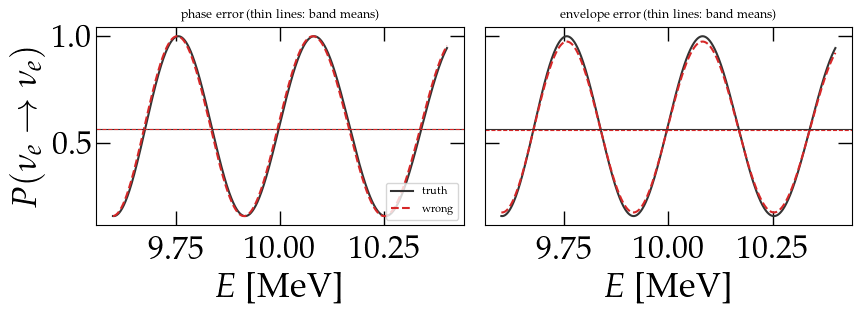

In [4]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.0, 3.4), sharey=True)
band = (E >= 9.6e6) & (E <= 10.4e6)
for ax, Q, title in ((ax0, phase_error(3.0e-4), 'phase error'),
                     (ax1, envelope_error(0.05), 'envelope error')):
    ax.plot(E[band]/1e6, P[band], color='0.2', label='truth')
    ax.plot(E[band]/1e6, Q[band], color='C3', ls='--', label='wrong')
    ax.axhline(P[band].mean(), color='0.2', lw=0.8)
    ax.axhline(Q[band].mean(), color='C3', lw=0.8, ls='--')
    ax.set_xlabel(r'$E$ [MeV]')
    ax.set_title('%s (thin lines: band means)' % title, fontsize=9)
ax0.set_ylabel(r'$P(\nu_e \to \nu_e)$')
ax0.legend(fontsize=8, loc='lower right')
fig.tight_layout()

The thin horizontal lines are what an experiment with this energy resolution would
actually measure. On the left they are nearly on top of each other; on the right they are
visibly apart, by the same fraction as the curves themselves.

## 2. Averaging needs cycles

The suppression is not unconditional. Below about two oscillations in the band there is nothing
for the average to cancel, and a phase error survives almost intact.

In [5]:
print('%-12s %-10s %-16s %s'
      % ('L [km]', 'cycles', 'phase suppr.', 'envelope suppr.'))
print('-'*54)
for L_km in (2.5e3, 5.0e3, 1.0e4, 2.0e4, 4.0e4):
    L = L_km*gd.UNIT_KM
    grid = np.linspace(9.0e6, 11.0e6, 8001)
    truth = np.asarray(oscprob.osc_prob_2nu_vacuum(grid, L, sth, Dm2,
                                                   nu_i=gd.NUE, nu_f=gd.NUE))
    n_cycles = (Dm2*L/(4*grid[0]) - Dm2*L/(4*grid[-1]))/np.pi
    shifted = np.asarray(oscprob.osc_prob_2nu_vacuum(grid*(1.0 + 1.0e-4), L, sth, Dm2,
                                                     nu_i=gd.NUE, nu_f=gd.NUE))
    ph = np.max(np.abs(shifted - truth))/abs(shifted.mean() - truth.mean())
    damped = 0.5 + (truth - 0.5)*0.98
    en = np.max(np.abs(damped - truth))/abs(damped.mean() - truth.mean())
    print('%-12.0f %-10.1f %-16.0f %.1f' % (L_km, n_cycles, ph, en))

L [km]       cycles     phase suppr.     envelope suppr.
------------------------------------------------------


2500         1.5        7                3.6


5000         3.1        67               5.7


10000        6.1        108              6.9


20000        12.2       96               6.0


40000        24.4       90               6.3


Two readings. The phase suppression climbs steeply from one to three cycles and then
settles around a hundred -- it does not grow without bound, because where the band edges fall
relative to the oscillation matters as much as how many cycles are inside it. The envelope
suppression sits near 6 throughout and never improves.

**The practical test**, and it needs no ground truth: *average your result over a few
oscillation lengths and see whether the discrepancy moves.* If it collapses, what you had was
a phase error, and the observable was fine all along. If it stays put, the error is real.

## 3. Asking for the averaged probability directly

You do not have to build the average by hand. `average=True` returns the exact decohered limit
-- the value the oscillation averages to when every relative phase is unresolvable -- and
`magnus.avgprob` exposes the machinery for a finite window.

In [6]:
analytic = float(np.asarray(oscprob.osc_prob_2nu_vacuum(
    1.0e7, BASELINE, sth, Dm2, nu_i=gd.NUE, nu_f=gd.NUE, average=True)))

print('analytic decohered limit (average=True) : %.6f' % analytic)
print('numerical mean over the 2 MeV band      : %.6f' % P.mean())
print('difference                              : %.2e' % abs(analytic - P.mean()))

analytic decohered limit (average=True) : 0.578012
numerical mean over the 2 MeV band      : 0.571933
difference                              : 6.08e-03


They differ in the third decimal, and that is not an error in either: the analytic
value is the infinite-window limit, while the band mean is over 6.1 cycles with the edges
falling where they fall. Asking for `average=True` where the phase has *not* averaged raises
`PhaseAveragingWarning` -- notebook 20 provokes it deliberately.

## Summary

| | phase error | envelope error |
|---|---|---|
| what it does | displaces the oscillation | changes its amplitude |
| suppressed by averaging | **~100x** | ~7x, fixed |
| improves with more cycles | yes, then plateaus | no |
| improves with a smaller error | no -- the ratio is scale-free | no |
| real instance | notebook 13, solar: **53x** | notebook 14, shock: **~1x** |
| is the observable affected? | barely | **yes** |

The reason notebook 14's shock error does not average away is physical rather than numerical: a
shock front changes the *adiabaticity* of the level crossing, so it moves the conversion
probability itself rather than the phase at which it oscillates. That is the error becoming an
envelope, and it is the one case in this package where the instantaneous error and the
observable error are the same number.

---

**Previous:** [Which engine answered, and why](22_magnus_which_engine_answered.ipynb)  
**Next:** [Performance](24_magnus_performance.ipynb) --- what is worth doing, and when each trick is worth nothing  
[API reference](https://mbustama.github.io/Magnus/functions.html) &middot; [Implementation details](https://mbustama.github.io/Magnus/implementation_details.html) &middot; [All notebooks](.)